# 序列到序列（上）

**Q**: 术语解释
- 源序列和目标序列


**Q**: 结合行文
- 问题的定义是什么？
- 问题的使用场景之一是什么？



## 数据生成

**Q**: 结合行文
- 简化的问题定义是什么？

**Q**: 回答问题
- 这是回归问题还是分类问题？
- 使用什么损失函数？


In [10]:
# 引入
from plots.chapter8 import *
from data_generation.square_sequences import generate_sequences


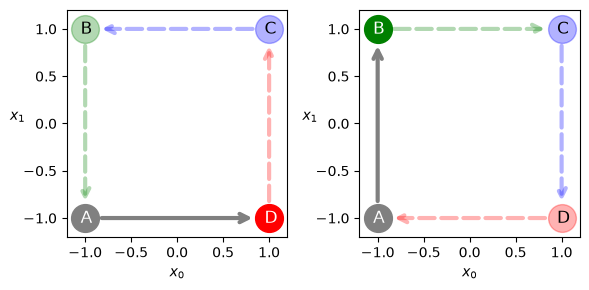

In [11]:
# 问题展示：绘制前两个角，求后两个
fig = counter_vs_clock(binary=False)

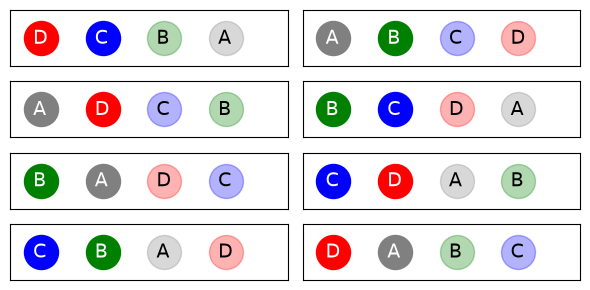

In [12]:
# 问题展示：所有可能的角序列（深色是源序列）
fig = plot_sequences(binary=False, target_len=2)

In [13]:
# 数据生成

points, directions = generate_sequences(n=256, seed=13)

print(points[0],directions[0])

[[-0.97083595  0.96103445]
 [-0.95248123 -1.00723632]
 [ 1.12690581 -0.9742751 ]
 [ 0.83357436  0.98782536]] 0


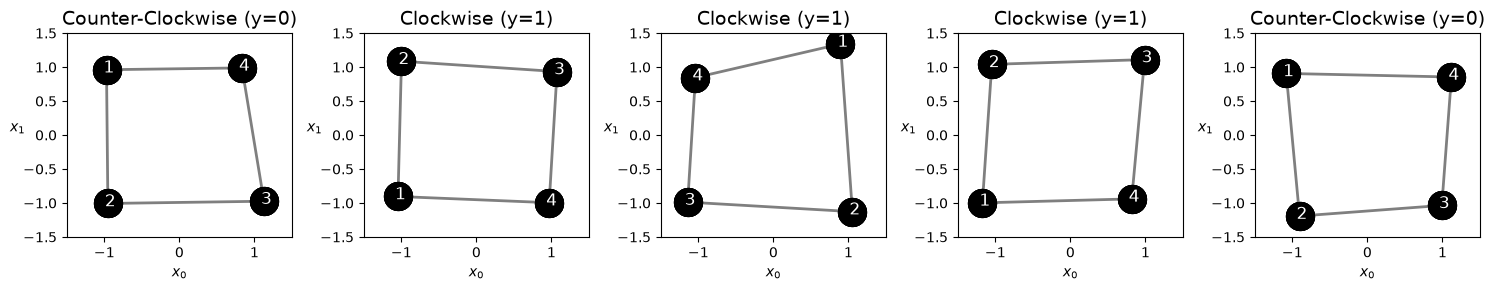

In [14]:
# 可视化数据：绘制顺序

fig = plot_data(points, directions, n_rows=1)

> 现在要处理问题是从源序列预测目标预测（如翻译英文成中文），简化成正方形问题就是给两个点，预测剩下两个点

> 另外这是个回归问题，自然使用MCE均方误差

# 解码器和解码器结构

**Q**: 解释术语
- 编码器和解码器

## 编码器

**Q**: 回顾
- 隐藏状态和序列的关系
- GRU解决了什么问题？

**Q**: 回答问题
- 编码器的目标是什么？

**Q**: 回答问题
- 最终隐藏状态隐藏了什么信息？


In [15]:
# 程序9-1-1: 编码器的结构和用途

class Encoder(nn.Module):
    def __init__(self, n_features, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.hidden = None
        self.basic_rnn = nn.GRU(self.n_features, self.hidden_dim, batch_first=True)
                
    def forward(self, X):        
        rnn_out, self.hidden = self.basic_rnn(X)
        
        return rnn_out # N, L, F

In [16]:
# 程序9-1-2: 拆分数据（源序列和目标序列）
full_seq = torch.tensor([[-1, -1], [-1, 1], [1, 1], [1, -1]]).float().view(1, 4, 2)
source_seq = full_seq[:, :2] # first two corners
target_seq = full_seq[:, 2:] # last two corners

In [ ]:
# 程序9-1-3: 使用编码器

torch.manual_seed(21)
encoder = Encoder(n_features=2, hidden_dim=2)
hidden_seq = encoder(source_seq) # output is N, L, F
hidden_final = hidden_seq[:, -1:]   # 手动取最后隐藏状态
print(hidden_final)

tensor([[[ 0.3105, -0.5263]]], grad_fn=<SliceBackward0>)


> 编码器就是RNN，只因最终隐藏状态是序列的最好代表，它编码了序列的相关信息，如方向等

## 解码器

**Q**: 解释术语
- token词元是什么意思？

**Q**: 回答问题
- 解码器的目标是什么？
- 解码器的计算逻辑是什么？
- 第一个输入应该是什么？
    - 正方形数据情况下
    - 一般情况下


![](images/decoder.png)

In [ ]:
# 程序9-2-1: 
class Decoder(nn.Module):
    def __init__(self, n_features, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.hidden = None
        self.basic_rnn = nn.GRU(self.n_features, self.hidden_dim, batch_first=True) 
        self.regression = nn.Linear(self.hidden_dim, self.n_features)
        
    def init_hidden(self, hidden_seq):
        # We only need the final hidden state
        hidden_final = hidden_seq[:, -1:] # N, 1, H
        # But we need to make it sequence-first
        self.hidden = hidden_final.permute(1, 0, 2) # 1, N, H                      
        
    def forward(self, X):
        # X is N, 1, F
        batch_first_output, self.hidden = self.basic_rnn(X, self.hidden) 
        
        last_output = batch_first_output[:, -1:]
        out = self.regression(last_output)
        
        # N, 1, F
        return out.view(-1, 1, self.n_features)               

In [ ]:
torch.manual_seed(21)
decoder = Decoder(n_features=2, hidden_dim=2)

# Initial hidden state will be encoder's final hidden state
decoder.init_hidden(hidden_seq)
# Initial data point is the last element of source sequence
inputs = source_seq[:, -1:]

target_len = 2
for i in range(target_len):
    print(f'Hidden: {decoder.hidden}')
    out = decoder(inputs)   # Predicts coordinates
    print(f'Output: {out}\n')
    # Predicted coordinates are next step's inputs
    inputs = out